# Classical ML Models — Rain in Australia

This notebook trains and evaluates four classical ML models for predicting **RainTomorrow** (binary):
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

All model pipelines are defined in `classical_models.py`.  
Tuning & calibration utilities are in `hyperparameter_tuning.py` and used in `classical_finetuning.ipynb`.  
Structured logging is provided by `training_logger.py`.

**Primary evaluation metric:** ROC-AUC (per cahier de charge).

## 1 — Imports & Constants

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import RocCurveDisplay
from classical_models import (
    get_all_models, evaluate_model,
    FEATURE_COLUMNS, TARGET_RAIN, LOCATION_COLUMN, DATA_PATH,
)
from training_logger import setup_logger, log_training_metrics, log_cv_results, log_model_save

from datetime import datetime
from tqdm.auto import tqdm

MODELS_DIR  = "saved_models/"
os.makedirs(MODELS_DIR, exist_ok=True)

# Setup structured logger
logger = setup_logger("classical_training")
logger.info("=== Classical Training Session Started ===")

def ts():
    return datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

print("Imports OK")

C:\Users\thiba\.conda\envs\crossvit_cy\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
22:55:17 | INFO | === Classical Training Session Started ===


Imports OK


## 2 — Data Loading

In [2]:
# Load the feature-engineered dataset
df = pd.read_csv(DATA_PATH)

# Schema validation
print("Columns:", df.columns.tolist())
print(f"Shape: {df.shape}")

# Extract features (excludes Location string column) and target
X = df[FEATURE_COLUMNS]
y = df[TARGET_RAIN]
print(f"\nFeature matrix: {X.shape}")
print(f"Rain prevalence: {y.mean():.2%}")
print(f"Locations available: {df[LOCATION_COLUMN].nunique()}")

logger.info(f"Data loaded: {X.shape[0]} rows, {X.shape[1]} features, rain={y.mean():.2%}")

22:55:17 | INFO | Data loaded: 142193 rows, 21 features, rain=22.42%


Columns: ['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Temp9am', 'Temp3pm', 'Month', 'DayOfYear', 'WeekOfYear', 'Quarter', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos', 'TempRange', 'TempMean', 'TempDiff_9_3', 'WindChill9am', 'WindChill3pm', 'HumidityChange', 'HumidityMean', 'PressureChange', 'PressureMean', 'DewPoint9am', 'DewPoint3pm', 'HeatIndex9am', 'HeatIndex3pm', 'WindDirGust_sin', 'WindDirGust_cos', 'WindDir9am_sin', 'WindDir9am_cos', 'WindDir3pm_sin', 'WindDir3pm_cos', 'WindSpeedChange', 'WindSpeedMean', 'StormFlag', 'RainToday_bin', 'RainRiskScore', 'TempHumidity_interact', 'Rainfall_lag1', 'Rainfall_lag2', 'Rainfall_lag7', 'Rainfall_roll3', 'Rainfall_roll7', 'Humidity3pm_lag1', 'Humidity3pm_lag2', 'Humidity3pm_lag7', 'Humidity3pm_roll3', 'Humidity3pm_roll7', 'MaxTemp_lag1', 'MaxTemp_lag2', 'MaxTemp_lag7', 'MaxTemp_roll3', 'MaxTemp_roll7', 'MinTemp_lag1'

## 3 — Train / Test Split

In [3]:
# Stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # Critical: preserve ~22% rain ratio
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Rain prevalence — Train: {y_train.mean():.2%}, Test: {y_test.mean():.2%}")

logger.info(f"Train/test split: train={X_train.shape}, test={X_test.shape}")

22:55:17 | INFO | Train/test split: train=(113754, 21), test=(28439, 21)


Train: (113754, 21), Test: (28439, 21)
Rain prevalence — Train: 22.42%, Test: 22.42%


## 4 — Model Instantiation Check

In [4]:
# Verify all 4 models instantiate without error
models = get_all_models()
for name, pipeline in models.items():
    clf_name = type(pipeline.steps[-1][1]).__name__
    print(f"{name}: {clf_name}")
    logger.info(f"Model instantiated: {name} ({clf_name})")

22:55:17 | INFO | Model instantiated: logistic_regression (LogisticRegression)
22:55:17 | INFO | Model instantiated: decision_tree (DecisionTreeClassifier)
22:55:17 | INFO | Model instantiated: random_forest (RandomForestClassifier)
22:55:17 | INFO | Model instantiated: xgboost (XGBClassifier)


logistic_regression: LogisticRegression
decision_tree: DecisionTreeClassifier
random_forest: RandomForestClassifier
xgboost: XGBClassifier


## 5 — Cross-Validation

In [5]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["roc_auc", "f1", "accuracy", "precision", "recall"]

cv_results = {}
for name, pipeline in tqdm(models.items(), desc="Cross-Validation", unit="model"):
    print(f"\nRunning CV for {name}...")
    scores = cross_validate(
        pipeline, X_train, y_train,
        cv=cv_strategy, scoring=scoring,
        n_jobs=-1, return_train_score=True,
        verbose=1
    )
    cv_results[name] = scores
    print(f"  ROC-AUC: {scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}")
    print(f"  F1:      {scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}")
    print(f"  Accuracy:{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}")
    
    # Structured logging
    log_cv_results(logger, name, scores)

print("\nCross-validation complete for all models.")

Cross-Validation:   0%|                                                                       | 0/4 [00:00<?, ?model/s]


Running CV for logistic_regression...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.0s finished
22:55:20 | INFO | [CV] logistic_regression cross-validation results:
22:55:20 | INFO |   roc_auc: 0.8543 ± 0.0041
22:55:20 | INFO |   f1: 0.6063 ± 0.0053
22:55:20 | INFO |   accuracy: 0.7804 ± 0.0028
22:55:20 | INFO |   precision: 0.5068 ± 0.0042
22:55:20 | INFO |   recall: 0.7544 ± 0.0078
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.          | 1/4 [00:02<00:06,  2.23s/model]


  ROC-AUC: 0.8543 ± 0.0041
  F1:      0.6063 ± 0.0053
  Accuracy:0.7804 ± 0.0028

Running CV for decision_tree...


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.9s finished
22:55:22 | INFO | [CV] decision_tree cross-validation results:
22:55:22 | INFO |   roc_auc: 0.8479 ± 0.0039
22:55:22 | INFO |   f1: 0.6036 ± 0.0043
22:55:22 | INFO |   accuracy: 0.7829 ± 0.0045
22:55:22 | INFO |   precision: 0.5110 ± 0.0071
22:55:22 | INFO |   recall: 0.7372 ± 0.0062
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.          | 2/4 [00:04<00:04,  2.19s/model]


  ROC-AUC: 0.8479 ± 0.0039
  F1:      0.6036 ± 0.0043
  Accuracy:0.7829 ± 0.0045

Running CV for random_forest...


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   26.4s finished
22:55:48 | INFO | [CV] random_forest cross-validation results:
22:55:48 | INFO |   roc_auc: 0.8764 ± 0.0033
22:55:48 | INFO |   f1: 0.6419 ± 0.0036
22:55:48 | INFO |   accuracy: 0.8169 ± 0.0023
22:55:48 | INFO |   precision: 0.5715 ± 0.0044
22:55:48 | INFO |   recall: 0.7321 ± 0.0045
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.          | 3/4 [00:30<00:13, 13.33s/model]


  ROC-AUC: 0.8764 ± 0.0033
  F1:      0.6419 ± 0.0036
  Accuracy:0.8169 ± 0.0023

Running CV for xgboost...


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    3.9s finished
22:55:53 | INFO | [CV] xgboost cross-validation results:
22:55:53 | INFO |   roc_auc: 0.8849 ± 0.0028
22:55:53 | INFO |   f1: 0.6504 ± 0.0026
22:55:53 | INFO |   accuracy: 0.8132 ± 0.0015
22:55:53 | INFO |   precision: 0.5603 ± 0.0026
22:55:53 | INFO |   recall: 0.7749 ± 0.0050
Cross-Validation: 100%|███████████████████████████████████████████████████████████████| 4/4 [00:35<00:00,  8.78s/model]

  ROC-AUC: 0.8849 ± 0.0028
  F1:      0.6504 ± 0.0026
  Accuracy:0.8132 ± 0.0015

Cross-validation complete for all models.


## 6 — Model Training & Evaluation

Train all models on the full training set and evaluate on the test set.

In [6]:
for name, pipeline in tqdm(models.items(), desc="Training models", unit="model"):
    print(f"\n⏳ Training {name}...")
    logger.info(f"Training {name}...")
    pipeline.fit(X_train, y_train)
    print(f"  {name} fitted.")
    
    # Evaluate on test set
    metrics = evaluate_model(pipeline, X_test, y_test)
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  ROC-AUC:   {metrics['roc_auc']:.4f}")
    print(f"  F1:        {metrics['f1_score']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    
    # Structured logging
    log_training_metrics(logger, name, metrics, phase="evaluation")
    
    # Save model
    model_path = os.path.join(MODELS_DIR, f"{name}.joblib")
    joblib.dump(pipeline, model_path)
    print(f"  Saved → {model_path}")
    log_model_save(logger, name, model_path)

print("\nAll models trained and saved!")

22:55:53 | INFO | Training logistic_regression...                                             | 0/4 [00:00<?, ?model/s]



⏳ Training logistic_regression...


22:55:53 | INFO | [EVALUATION] logistic_regression metrics:
22:55:53 | INFO |   accuracy: 0.7855
22:55:53 | INFO |   roc_auc: 0.8588
22:55:53 | INFO |   f1_score: 0.6123
22:55:53 | INFO |   precision: 0.5147
22:55:53 | INFO |   recall: 0.7556
22:55:53 | INFO |   confusion_matrix: [[17522, 4542], [1558, 4817]]
22:55:53 | INFO | [SAVE] logistic_regression → saved_models/logistic_regression.joblib
22:55:53 | INFO | Training decision_tree...                                           | 1/4 [00:00<00:00,  3.23model/s]


  logistic_regression fitted.
  Accuracy:  0.7855
  ROC-AUC:   0.8588
  F1:        0.6123
  Precision: 0.5147
  Recall:    0.7556
  Saved → saved_models/logistic_regression.joblib

⏳ Training decision_tree...


22:55:54 | INFO | [EVALUATION] decision_tree metrics:
22:55:54 | INFO |   accuracy: 0.7938
22:55:54 | INFO |   roc_auc: 0.8526
22:55:54 | INFO |   f1_score: 0.6132
22:55:54 | INFO |   precision: 0.5291
22:55:54 | INFO |   recall: 0.7291
22:55:54 | INFO |   confusion_matrix: [[17928, 4136], [1727, 4648]]
22:55:54 | INFO | [SAVE] decision_tree → saved_models/decision_tree.joblib
22:55:54 | INFO | Training random_forest...███████████                                | 2/4 [00:01<00:01,  1.49model/s]


  decision_tree fitted.
  Accuracy:  0.7938
  ROC-AUC:   0.8526
  F1:        0.6132
  Precision: 0.5291
  Recall:    0.7291
  Saved → saved_models/decision_tree.joblib

⏳ Training random_forest...
  random_forest fitted.


22:55:59 | INFO | [EVALUATION] random_forest metrics:
22:55:59 | INFO |   accuracy: 0.8232
22:55:59 | INFO |   roc_auc: 0.8816
22:55:59 | INFO |   f1_score: 0.6509
22:55:59 | INFO |   precision: 0.5840
22:55:59 | INFO |   recall: 0.7352
22:55:59 | INFO |   confusion_matrix: [[18725, 3339], [1688, 4687]]
22:55:59 | INFO | [SAVE] random_forest → saved_models/random_forest.joblib
22:55:59 | INFO | Training xgboost...█████████████████████████████████                | 3/4 [00:06<00:02,  2.66s/model]


  Accuracy:  0.8232
  ROC-AUC:   0.8816
  F1:        0.6509
  Precision: 0.5840
  Recall:    0.7352
  Saved → saved_models/random_forest.joblib

⏳ Training xgboost...


C:\Users\thiba\.conda\envs\crossvit_cy\lib\site-packages\xgboost\core.py:158: UserWarning: [22:55:59] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
22:56:00 | INFO | [EVALUATION] xgboost metrics:
22:56:00 | INFO |   accuracy: 0.8174
22:56:00 | INFO |   roc_auc: 0.8893
22:56:00 | INFO |   f1_score: 0.6569
22:56:00 | INFO |   precision: 0.5674
22:56:00 | INFO |   recall: 0.7799
22:56:00 | INFO |   confusion_matrix: [[18273, 3791], [1403, 4972]]
22:56:00 | INFO | [SAVE] xgboost → saved_models/xgboost.joblib
Training models: 100%|████████████████████████████████████████████████████████████████| 4/4 [00:07<00:00,  1.78s/model]

  xgboost fitted.
  Accuracy:  0.8174
  ROC-AUC:   0.8893
  F1:        0.6569
  Precision: 0.5674
  Recall:    0.7799
  Saved → saved_models/xgboost.joblib

All models trained and saved!


## 7 — ROC Curves

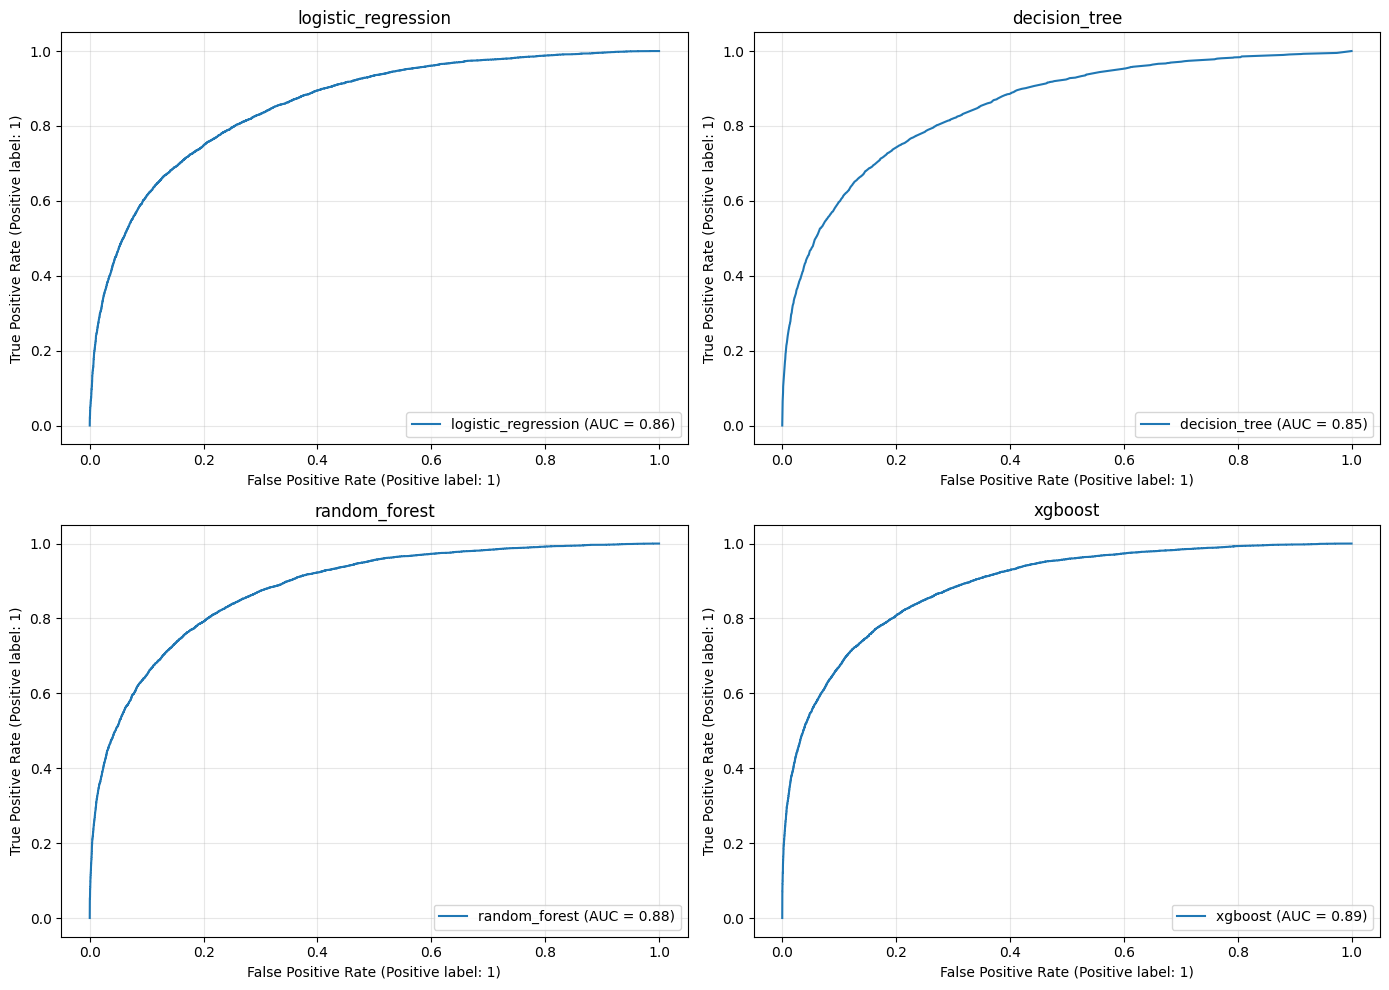

ROC curves saved to artifacts/roc_curves_classical.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (name, pipeline) in zip(axes, models.items()):
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, name=name)
    ax.set_title(f"{name}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("artifacts/roc_curves_classical.png", dpi=150, bbox_inches="tight")
plt.show()
print("ROC curves saved to artifacts/roc_curves_classical.png")

## 8 — Results Summary Table

In [8]:
summary_rows = []
for name, pipeline in models.items():
    metrics = evaluate_model(pipeline, X_test, y_test)
    summary_rows.append({"Model": name, **metrics})

summary_df = pd.DataFrame(summary_rows).set_index("Model")
summary_df = summary_df.drop(columns=['confusion_matrix'])
print(summary_df.sort_values("roc_auc", ascending=False).to_markdown())

| Model               |   accuracy |   roc_auc |   f1_score |   precision |   recall |
|:--------------------|-----------:|----------:|-----------:|------------:|---------:|
| xgboost             |   0.817363 |  0.88928  |   0.65689  |    0.567386 | 0.779922 |
| random_forest       |   0.823236 |  0.88159  |   0.650927 |    0.583977 | 0.735216 |
| logistic_regression |   0.785506 |  0.858799 |   0.612305 |    0.514692 | 0.755608 |
| decision_tree       |   0.793839 |  0.852552 |   0.613233 |    0.529144 | 0.729098 |


## 9 — Temperature Regressor Training

Train a **GradientBoostingRegressor** pipeline to predict `MaxTemp`.

**Important:** `MaxTemp` is in `FEATURE_COLUMNS` — we remove it from X when predicting it to avoid data leakage.

In [9]:
from classical_models import build_temp_regressor, evaluate_regressor, TARGET_TEMP

# --- Prepare temperature features (remove MaxTemp to avoid leakage) ---
temp_features = [c for c in FEATURE_COLUMNS if c != "MaxTemp"]

# Drop rows where MaxTemp is NaN
df_temp = df.dropna(subset=['MaxTemp']).copy()

X_temp = df_temp[temp_features]
y_temp = df_temp[TARGET_TEMP]

# --- Chronological 80/20 split (no shuffle — preserve temporal order) ---
split_idx = int(len(X_temp) * 0.8)
X_temp_train, X_temp_test = X_temp.iloc[:split_idx], X_temp.iloc[split_idx:]
y_temp_train, y_temp_test = y_temp.iloc[:split_idx], y_temp.iloc[split_idx:]

print(f"Temp Train: {X_temp_train.shape}, Temp Test: {X_temp_test.shape}")
print(f"MaxTemp range — Train: [{y_temp_train.min():.1f}, {y_temp_train.max():.1f}], "
      f"Test: [{y_temp_test.min():.1f}, {y_temp_test.max():.1f}]")

logger.info(f"Temp regressor data: train={X_temp_train.shape}, test={X_temp_test.shape}")

22:56:02 | INFO | Temp regressor data: train=(113754, 20), test=(28439, 20)


Temp Train: (113754, 20), Temp Test: (28439, 20)
MaxTemp range — Train: [-4.8, 47.3], Test: [2.6, 48.1]


## 10 — Temperature Regressor Evaluation & Save

In [10]:
# --- Build and fit the temperature regressor ---
temp_model = build_temp_regressor()
print("⏳ Fitting temperature regressor...")
logger.info("Fitting temperature regressor...")
temp_model.fit(X_temp_train, y_temp_train)
print("Temperature regressor fitted.")

# --- Evaluate ---
temp_metrics = evaluate_regressor(temp_model, X_temp_test, y_temp_test)
print(f"Temperature Regressor Results:")
print(f"  MAE : {temp_metrics['mae']:.4f}")
print(f"  R²  : {temp_metrics['r2']:.4f}")

log_training_metrics(logger, "temp_regressor", temp_metrics, phase="evaluation")

# --- Save ---
temp_model_path = os.path.join(MODELS_DIR, "temp_regressor.joblib")
joblib.dump(temp_model, temp_model_path)
print(f"\nSaved temperature regressor → {temp_model_path}")
log_model_save(logger, "temp_regressor", temp_model_path)

22:56:02 | INFO | Fitting temperature regressor...


⏳ Fitting temperature regressor...


22:56:53 | INFO | [EVALUATION] temp_regressor metrics:
22:56:53 | INFO |   mae: 0.4420
22:56:53 | INFO |   r2: 0.9925
22:56:53 | INFO | [SAVE] temp_regressor → saved_models/temp_regressor.joblib


Temperature regressor fitted.
Temperature Regressor Results:
  MAE : 0.4420
  R²  : 0.9925

Saved temperature regressor → saved_models/temp_regressor.joblib
